- Número de Conversas: 1000
- Limite de paralelismo por engine: 10
- Modelo: Llama 3.1-8B Instruct
- Engines: 2
- Escalonadores: FCFS, PLAS, PLAS KV Token-time
- Load Balancers: Round Robin, Least Total Load, Autellix, Autellix Threshold: Total Load, Running Requests, KV Cache Occupation
- Prog/s: 0.5 1 2 4 8
- Limite de Output Tokens: 100
- Burstiness:1
- Tamanho Janela de Contexto: 40.000 tokens


## Comparar Load Balancer

In [1]:
Y_METRIC = "p99_e2el_per_program"

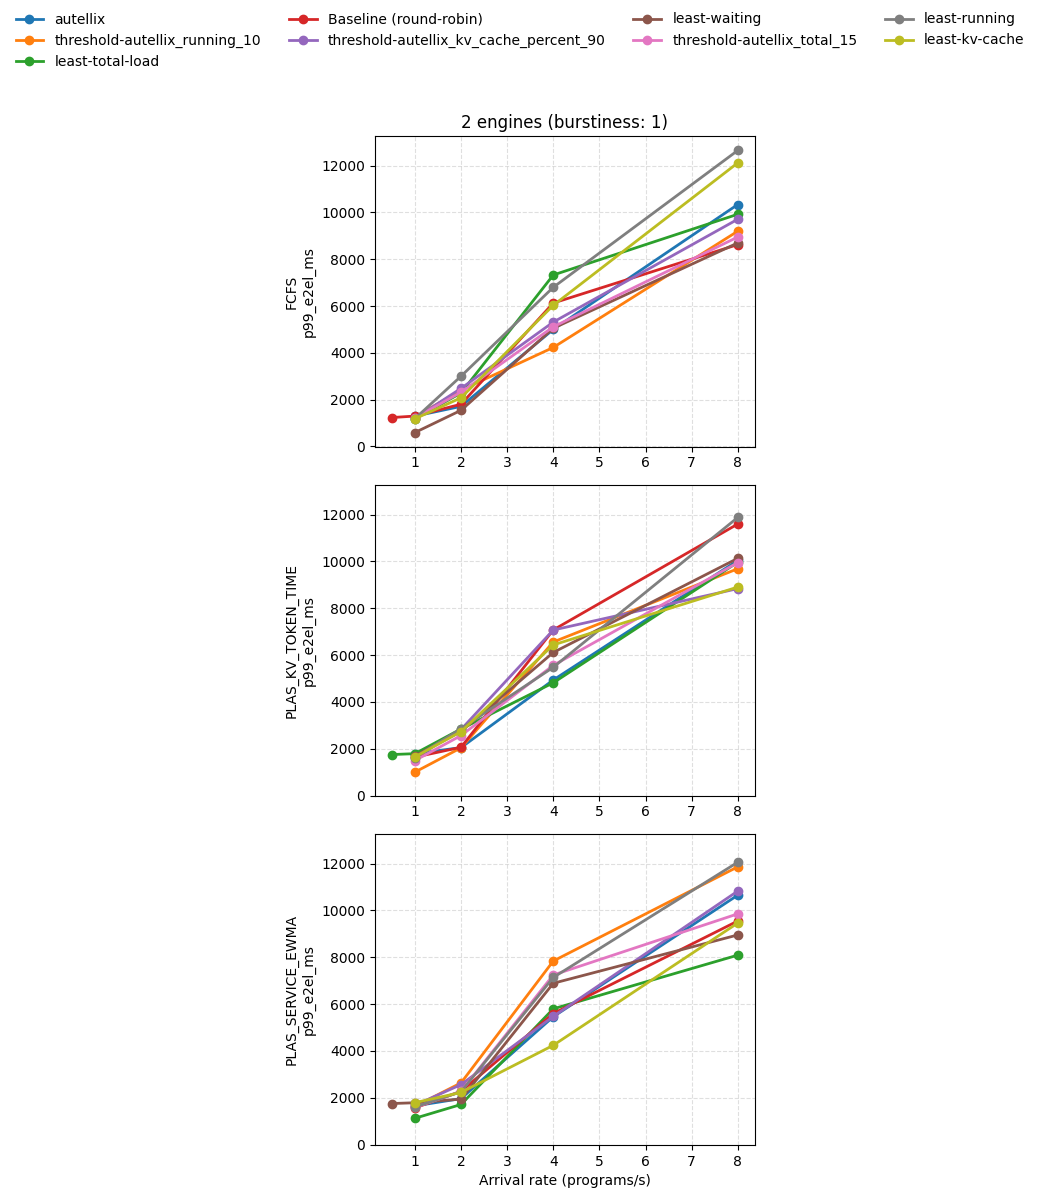

In [2]:
import json
import glob
import re
import matplotlib.pyplot as plt
from collections import defaultdict

# ============================================================
# CONFIG
# ============================================================
OUTPUT_DIRS = {
    #"Llama3.1-8B": "outputs_benchmark_50_25_LLama_2GPU",
    "2 engines (burstiness: 1)": "outputs/program_arrivalrate",
    # "4 engines": "outputs_4_engines",
}

SCHEDULERS = ["fcfs", "plas_kv_token_time", "plas_service_ewma"]

# FIX 1: Uncommented Y_METRIC
Y_METRIC = "p99_e2el_ms"

# Optional: fixed colors for consistency
COLORS = {
    "round-robin": "#2ca02c",   # Verde
    "autellix": "#d62728",      # Vermelho
    "least-kv-cache": "#ff7f0e",   # Laranja
    "least-running": "#1f77b4",    # Azul
    "least-total-load": "#9467bd", # Roxo
    "least-waiting": "#8c564b",    # Marrom

    "threshold-autelix_kv_cache_percent_90": "#ffbb78",  # Laranja claro
    "threshold-autelix_running_10": "#aec7e8",           # Azul claro
    "threshold-autelix_total_15": "#c5b0d5",             # Roxo claro
}

# results[engine][scheduler][strategy][rate] = [values]
results = defaultdict(
    lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
)

# FIX 2: Dynamic Regex using known schedulers
# This matches: (baseline_)?output_(scheduler)_(everything_else)_rate(numbers)_run...
schedulers_regex = "|".join(SCHEDULERS)
pattern = re.compile(
    rf"(baseline_)?output_({schedulers_regex})_(.*)_rate([\d.]+)_run\d+\.json"
)

# ============================================================
# LOAD DATA
# ============================================================
for engine_label, folder in OUTPUT_DIRS.items():
    for path in glob.glob(f"{folder}/*.json"):
        filename = path.split("/")[-1]
        match = pattern.match(filename)
        
        if not match:
            continue

        is_baseline = match.group(1) is not None
        scheduler = match.group(2)
        strategy = match.group(3)
        rate = float(match.group(4))

        if is_baseline:
            strategy = f"Baseline ({strategy})"

        with open(path) as f:
            data = json.load(f)

        value = data["full_metrics"][Y_METRIC]
        results[engine_label][scheduler][strategy][rate].append(value)

# ============================================================
# PLOTTING
# ============================================================
n_rows = len(SCHEDULERS)
n_cols = len(OUTPUT_DIRS)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharey=True
)

# CORRECT normalization
if n_cols == 1:
    axes = axes.reshape(n_rows, 1)
elif n_rows == 1:
    axes = axes.reshape(1, n_cols)

for col, (engine_label, _) in enumerate(OUTPUT_DIRS.items()):
    for row, scheduler in enumerate(SCHEDULERS):
        ax = axes[row, col]

        for strategy, rate_dict in results[engine_label][scheduler].items():
            rates = sorted(rate_dict.keys())
            values = [
                sum(rate_dict[r]) / len(rate_dict[r]) for r in rates
            ]

            # Optional: Match colors to strategy if defined in COLORS dict
            # color = COLORS.get(strategy, None) 
            
            ax.plot(
                rates,
                values,
                marker="o",
                linewidth=2,
                label=strategy
            )

        if row == 0:
            ax.set_title(engine_label)

        if col == 0:
            ax.set_ylabel(f"{scheduler.upper()}\n{Y_METRIC}")

        if row == n_rows - 1:
            ax.set_xlabel("Arrival rate (programs/s)")

        ax.grid(True, linestyle="--", alpha=0.4)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=min(len(labels), 4), # Wrapped columns so it doesn't run off screen
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# Comparar Scheduler

In [29]:
Y_METRIC = "p99_e2el_ms"
LOAD_BALANCER ="round-robin"

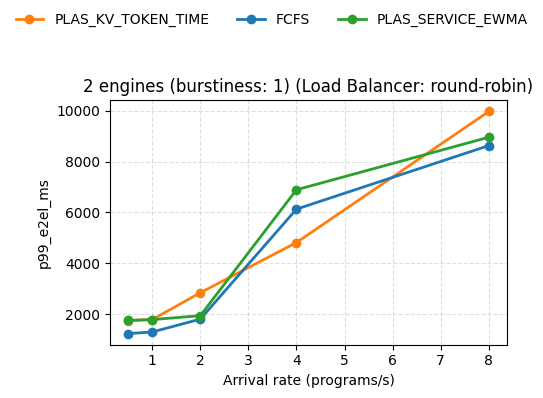

In [30]:
import json
import glob
import re
import matplotlib.pyplot as plt
from collections import defaultdict

# ============================================================
# CONFIG
# ============================================================
MODELS = {
    #"Llama3.1-8B": "outputs_benchmark_50_25_LLama_2GPU",
    "2 engines (burstiness: 1)": "outputs/program_arrivalrate",
    # "4 engines": "outputs_4_engines",
}

SCHEDULERS = ["fcfs", "plas_kv_token_time", "plas_service_ewma"]

SCHEDULER_COLORS = {
    "fcfs": "#1f77b4",               # Azul
    "plas_kv_token_time": "#ff7f0e", # Laranja
    "plas_service_ewma": "#2ca02c",  # Verde
}

# ============================================================
# DATA STRUCTURE
# ============================================================
results = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

# Regex dinâmico baseado nos SCHEDULERS atualizados.
# Nota: Ele continua travado em "_round-robin_". Se quiser ler as outras 
# estratégias (como autellix), será necessário trocar "round-robin" por "(.*)".
schedulers_regex = "|".join(SCHEDULERS)
pattern = re.compile(
    rf"(baseline_)?output_({schedulers_regex})_{LOAD_BALANCER}_rate([\d.]+)_run\d+\.json"
)

# ============================================================
# LOAD DATA
# ============================================================
for model_label, folder in MODELS.items():
    for path in glob.glob(f"{folder}/*.json"):
        filename = path.split("/")[-1]
        match = pattern.match(filename)
        
        if not match:
            continue

        is_baseline = match.group(1) is not None
        base_scheduler = match.group(2)
        rate = float(match.group(3))

        # Se for baseline, criamos uma chave separada no dicionário
        scheduler_key = base_scheduler

        with open(path) as f:
            data = json.load(f)

        value = data["full_metrics"][Y_METRIC]
        results[model_label][scheduler_key][rate].append(value)

# ============================================================
# PLOTTING
# ============================================================
n_cols = len(MODELS)

fig, axes = plt.subplots(
    1,
    n_cols,
    figsize=(5 * n_cols, 4),
    sharey=True
)

# Normalize axes when only one model
if n_cols == 1:
    axes = [axes]

for col, (model_label, _) in enumerate(MODELS.items()):
    ax = axes[col]

    for scheduler_key, rate_dict in results[model_label].items():
        if not rate_dict:
            continue

        rates = sorted(rate_dict.keys())
        values = [
            sum(rate_dict[r]) / len(rate_dict[r]) for r in rates
        ]

        # Identifica propriedades de estilo baseadas em ser baseline ou não
        is_baseline = scheduler_key.startswith("baseline_")
        original_scheduler = scheduler_key.replace("baseline_", "")
        
        # Configurações visuais dinâmicas
        label = f"Baseline ({original_scheduler.upper()})" if is_baseline else scheduler_key.upper()
        color = SCHEDULER_COLORS.get(original_scheduler, "#333")
        linestyle = "--" if is_baseline else "-"
        marker = "x" if is_baseline else "o"

        ax.plot(
            rates,
            values,
            marker=marker,
            linestyle=linestyle,
            linewidth=2,
            label=label,
            color=color,
        )

    ax.set_title(model_label + f" (Load Balancer: {LOAD_BALANCER})")
    ax.set_xlabel("Arrival rate (programs/s)")
    ax.grid(True, linestyle="--", alpha=0.4)

# Shared Y label
axes[0].set_ylabel(f"{Y_METRIC}")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=min(len(labels), 3), # Limitei em 3 colunas para a legenda não ficar muito esticada
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.85]) # Ajustado o espaço do topo para caber as 3 ou 6 legendas
plt.show()

# Kv cache usage



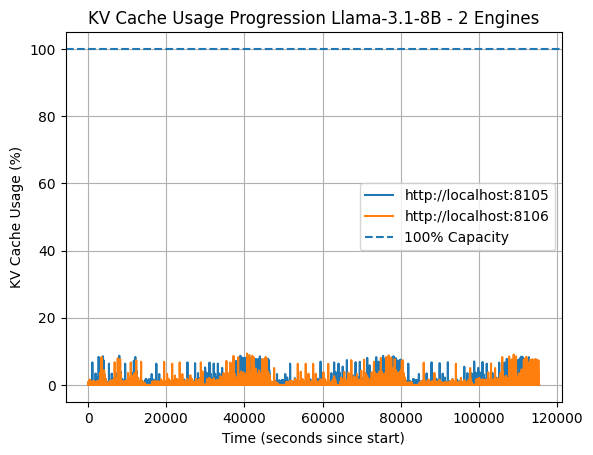

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
#df = pd.read_csv("outputs_benchmark_50_25_LLama_2GPU/kv_cache_usage.csv")
df = pd.read_csv("outputs/program_arrivalrate/kv_cache_usage.csv")
# Sort by timestamp (important when mixing engines)
df = df.sort_values("timestamp")

# Normalize time to start at 0 (global start)
df["time_sec"] = df["timestamp"] - df["timestamp"].iloc[0]

# Plot
plt.figure()

# Plot one line per backend (engine)
for backend, group in df.groupby("backend"):
    group = group.sort_values("timestamp")
    plt.plot(
        group["time_sec"],
        group["kv_cache_percent"],
        label=f"{backend}"
    )

# 100% reference line
plt.axhline(100, linestyle="--", label="100% Capacity")

plt.xlabel("Time (seconds since start)")
plt.ylabel("KV Cache Usage (%)")
plt.title("KV Cache Usage Progression Llama-3.1-8B - 2 Engines")
plt.legend()
plt.grid(True)

plt.show()

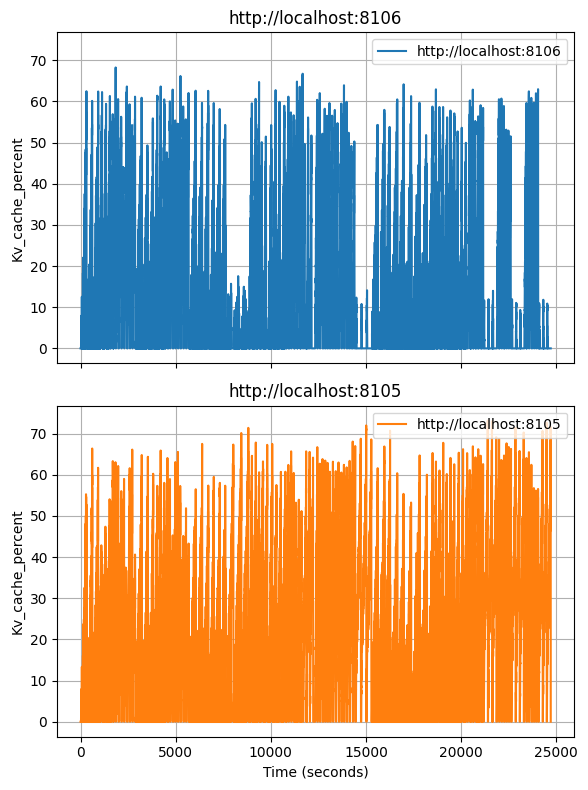

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

metric = "kv_cache_percent"

# Load CSV
df = pd.read_csv("outputs_llama_50_2gpu_burstiness_005/kv_cache_usage.csv")

# Sort by timestamp
df = df.sort_values("timestamp")

# Normalize time
df["time_sec"] = df["timestamp"] - df["timestamp"].iloc[0]

# Get unique backends
backends = df["backend"].unique()

# Mapa de cores (uma por backend)
colors = plt.cm.tab10.colors
color_map = {backend: colors[i % len(colors)] for i, backend in enumerate(backends)}

# Create subplots (N linhas, 1 coluna)  ← mudou aqui
fig, axes = plt.subplots(len(backends), 1, figsize=(6, 4 * len(backends)), sharex=True, sharey=True)

# Se só tiver 1 backend
if len(backends) == 1:
    axes = [axes]

# Plot each backend
for ax, backend in zip(axes, backends):
    group = df[df["backend"] == backend].sort_values("timestamp")
    
    ax.plot(
        group["time_sec"],
        group[metric],
        color=color_map[backend],  # cor fixa
        label=backend
    )
    
    ax.set_title(f"{backend}")
    ax.set_ylabel(f"{metric.capitalize()}")
    ax.grid(True)
    ax.legend(loc="upper right")

# X label só no último subplot
axes[-1].set_xlabel("Time (seconds)")

# plt.axhline(10, linestyle="--")

plt.tight_layout()
plt.show()

In [21]:
Y_METRIC = "output_token_throughput"

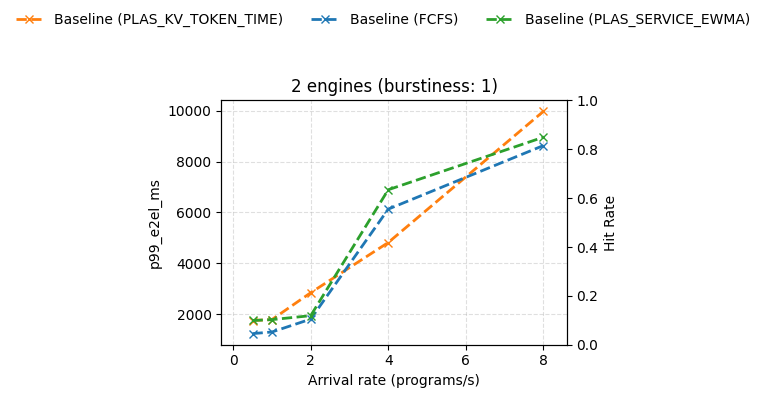

In [ ]:
import json
import glob
import re
import matplotlib.pyplot as plt
from collections import defaultdict



MODELS = {
    #"Llama3.1-8B": "outputs_benchmark_50_25_LLama_2GPU",
    "2 engines (burstiness: 1)": "outputs/program_arrivalrate",
    # "4 engines": "outputs_4_engines",
}

SCHEDULERS = ["fcfs", "plas_kv_token_time", "plas_service_ewma"]

SCHEDULER_COLORS = {
    "fcfs": "#1f77b4",               # Azul
    "plas_kv_token_time": "#ff7f0e", # Laranja
    "plas_service_ewma": "#2ca02c",  # Verde
}

# ============================================================
# DATA STRUCTURE
# ============================================================
results = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
hit_rates = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))


# Regex dinâmico baseado nos SCHEDULERS atualizados.
# Nota: Ele continua travado em "_round-robin_". Se quiser ler as outras 
# estratégias (como autellix), será necessário trocar "round-robin" por "(.*)".
schedulers_regex = "|".join(SCHEDULERS)
pattern = re.compile(
    rf"(baseline_)?output_({schedulers_regex})_{LOAD_BALANCER}_rate([\d.]+)_run\d+\.json"
)

# ============================================================
# LOAD DATA
# ============================================================
for model_label, folder in MODELS.items():
    for path in glob.glob(f"{folder}/*.json"):
        filename = path.split("/")[-1]
        match = pattern.match(filename)
        if not match:
            continue

        scheduler = match.group(1)
        rate = float(match.group(2))

        if scheduler not in SCHEDULERS:
            continue

        with open(path) as f:
            data = json.load(f)

        # Primary metric
        value = data["full_metrics"][Y_METRIC]
        results[model_label][scheduler][rate].append(value)

        # Hit rate (engine_0 only)
        try:
            hit = data["full_metrics"]["prefix_cache"]["engine_0"]["hit_rate"]
        except KeyError:
            hit = 0

        hit_rates[model_label][scheduler][rate].append(hit)

# ============================================================
# PLOTTING
# ============================================================
n_cols = len(MODELS)

fig, axes = plt.subplots(
    1,
    n_cols,
    figsize=(5 * n_cols, 4),
    sharey=True
)

if n_cols == 1:
    axes = [axes]

for col, (model_label, _) in enumerate(MODELS.items()):
    ax = axes[col]
    ax2 = ax.twinx()  # secondary axis for hit rate

    width = 1
    offset_mult = -0.5

    for i, scheduler in enumerate(SCHEDULERS):
        rate_dict = results[model_label][scheduler]
        hit_dict = hit_rates[model_label][scheduler]

        if not rate_dict:
            continue

        rates = sorted(rate_dict.keys())

        values = [
            sum(rate_dict[r]) / len(rate_dict[r]) for r in rates
        ]

        hits = [
            sum(hit_dict[r]) / len(hit_dict[r]) for r in rates
        ]

        # ---------- BACKGROUND BARS ----------
        offsets = [r + (i + offset_mult) * width for r in rates]

        ax2.bar(
            offsets,
            hits,
            width=width,
            alpha=0.5,
            color=SCHEDULER_COLORS.get(scheduler),
        )

        # ---------- LINE ----------
        ax.plot(
            rates,
            values,
            marker="o",
            linewidth=2,
            label=scheduler.upper(),
            color=SCHEDULER_COLORS.get(scheduler),
        )

    ax.set_title(model_label)
    ax.set_xlabel("Arrival rate (programs/s)")
    ax.grid(True, linestyle="--", alpha=0.4)

    ax2.set_ylim(0, 1)
    ax2.set_ylabel("Hit Rate")

# Shared Y label
axes[0].set_ylabel(f"{Y_METRIC}")

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(labels),
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()


# GoodPut

In [3]:
TARGET_RATE = 1.0
Y_METRIC_GOODPUT = "p99_e2el_per_program" 

Plotando gráficos usando a Arrival Rate alvo: 1.0


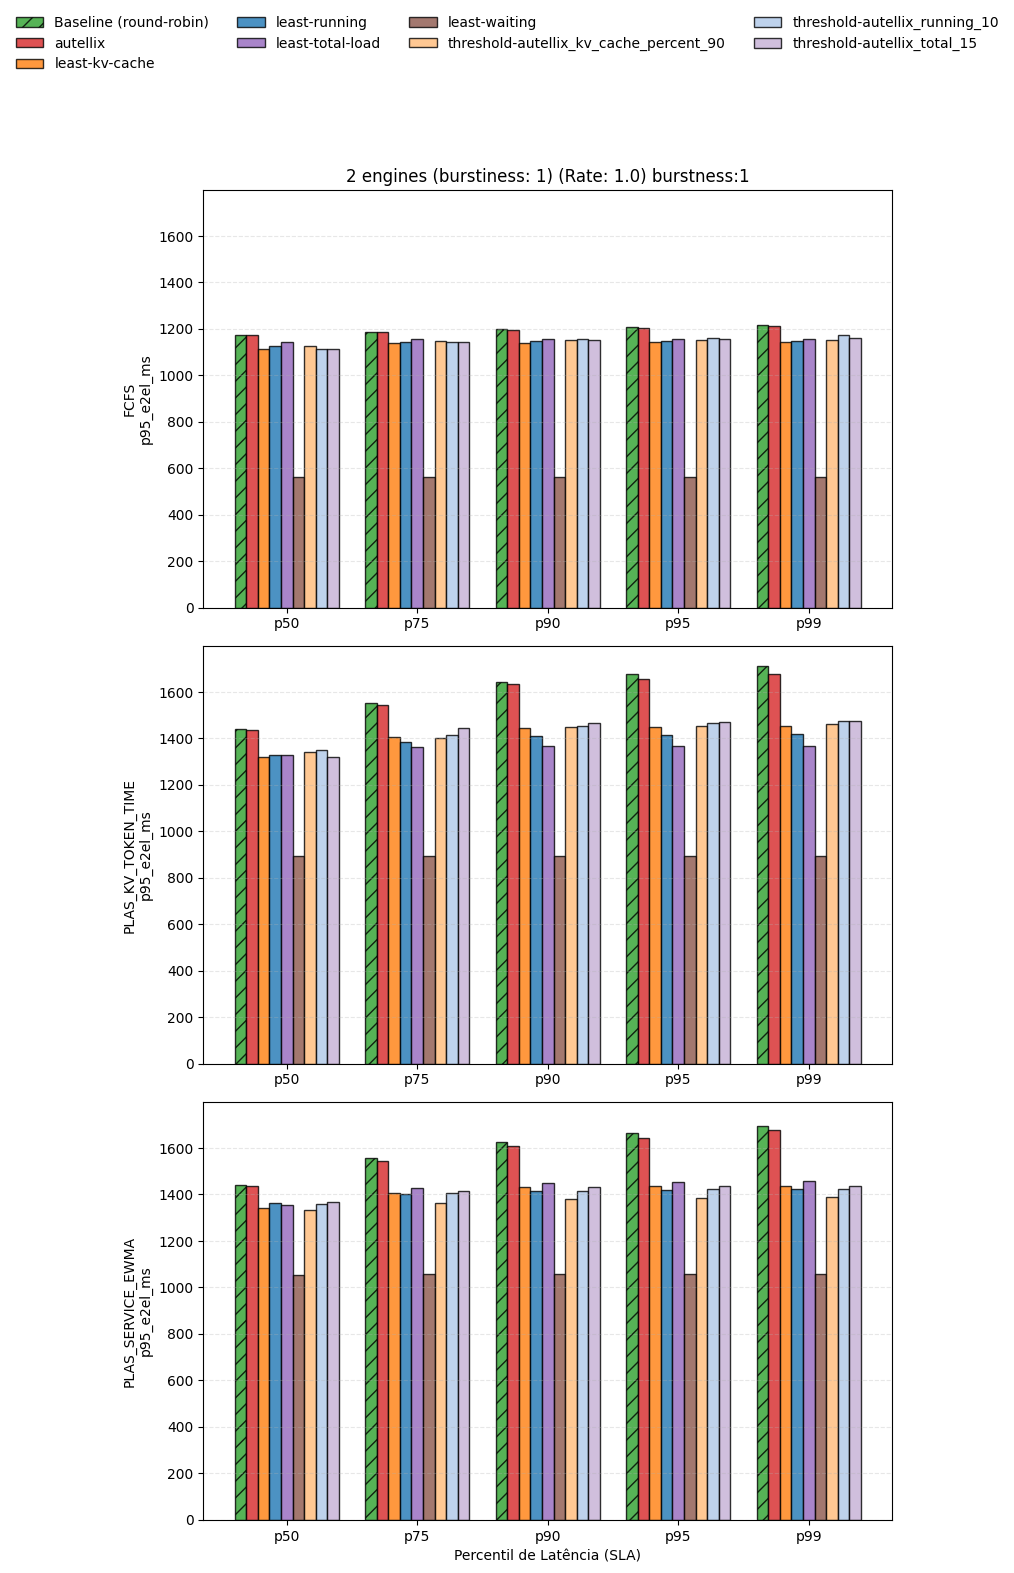

In [4]:
import json
import glob
import re
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# ============================================================
# CONFIG
# ============================================================
OUTPUT_DIRS = {
    #"Llama3.1-8B": "outputs_benchmark_50_25_LLama_2GPU",
    "2 engines (burstiness: 1)": "outputs/program_arrivalrate",
    # "4 engines": "outputs_4_engines",
}

SCHEDULERS = ["fcfs", "plas_kv_token_time", "plas_service_ewma"]
Y_METRIC_GOODPUT = "p95_e2el_ms" 
BURSTNESS = "1"

# Dicionário de cores fixas para cada estratégia
STRATEGY_COLORS = {
    "round-robin": "#2ca02c",   # Verde
    "autellix": "#d62728",      # Vermelho
    "least-kv-cache": "#ff7f0e",   # Laranja
    "least-running": "#1f77b4",    # Azul
    "least-total-load": "#9467bd", # Roxo
    "least-waiting": "#8c564b",    # Marrom

    "threshold-autellix_kv_cache_percent_90": "#ffbb78",  # Laranja claro
    "threshold-autellix_running_10": "#aec7e8",           # Azul claro
    "threshold-autellix_total_15": "#c5b0d5",             # Roxo claro
}

results_goodput = defaultdict(
    lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(lambda: defaultdict(list))))
)

# FIX 1: Regex dinâmico para não quebrar com os underscores nos nomes
schedulers_regex = "|".join(SCHEDULERS)
pattern = re.compile(
    rf"(baseline_)?output_({schedulers_regex})_(.*)_rate([\d.]+)_run\d+\.json"
)

# ============================================================
# LOAD DATA
# ============================================================
for engine_label, folder in OUTPUT_DIRS.items():
    for path in glob.glob(f"{folder}/*.json"):
        filename = path.split("/")[-1]
        match = pattern.match(filename)
        if not match:
            continue

        is_baseline = match.group(1) is not None
        scheduler = match.group(2)
        strategy = match.group(3)
        rate = float(match.group(4))

        if is_baseline:
            strategy = f"Baseline ({strategy})"

        try:
            with open(path) as f:
                data = json.load(f)
            
            if "full_latency_separation" in data:
                metrics_dict = data["full_latency_separation"].get("metrics_per_percentile", {})
                
                for p_key, p_data in metrics_dict.items():
                    if Y_METRIC_GOODPUT in p_data and p_data[Y_METRIC_GOODPUT] is not None:
                        val = p_data[Y_METRIC_GOODPUT]
                        results_goodput[engine_label][scheduler][strategy][rate][p_key].append(val)
                        
        except Exception as e:
            print(f"Error loading {path}: {e}")

# ============================================================
# PLOTTING
# ============================================================

print(f"Plotando gráficos usando a Arrival Rate alvo: {TARGET_RATE}")

PERCENTILES = ["50", "75", "90", "95", "99"]

n_rows = len(SCHEDULERS)
n_cols = len(OUTPUT_DIRS)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(8 * n_cols, 5 * n_rows),
    sharey=True
)

if n_cols == 1 and n_rows == 1:
    axes = np.array([[axes]])
elif n_cols == 1:
    axes = axes.reshape(n_rows, 1)
elif n_rows == 1:
    axes = axes.reshape(1, n_cols)

# Coletar e ordenar todas as estratégias de forma global e unificada
all_strategies = set()
for e_dict in results_goodput.values():
    for s_dict in e_dict.values():
        all_strategies.update(s_dict.keys())

fixed_strategies = sorted(list(all_strategies))

for col, engine_label in enumerate(OUTPUT_DIRS.keys()):
    for row, scheduler in enumerate(SCHEDULERS):
        ax = axes[row, col]
        
        x = np.arange(len(PERCENTILES))
        width = 0.8 / len(fixed_strategies) if fixed_strategies else 0.8
        
        for i, strategy in enumerate(fixed_strategies):
            avg_goodputs = []
            for p in PERCENTILES:
                raw_values = results_goodput[engine_label][scheduler].get(strategy, {}).get(TARGET_RATE, {}).get(p, [])
                valid_values = [v for v in raw_values if v is not None]
                
                if valid_values:
                    avg_goodputs.append(sum(valid_values) / len(valid_values))
                else:
                    avg_goodputs.append(0) 
            
            offset = (i - len(fixed_strategies) / 2 + 0.5) * width
            
            # FIX 2: Garantir que a baseline pegue a cor original (removendo "Baseline (" do nome)
            base_strategy = strategy.replace("Baseline (", "").replace(")", "")
            bar_color = STRATEGY_COLORS.get(base_strategy, "gray")
            
            # Opcional: Adiciona hachuras (listras) na barra do baseline para destacá-lo
            bar_hatch = "//" if "Baseline" in strategy else ""
            
            ax.bar(
                x + offset, 
                avg_goodputs, 
                width, 
                label=strategy, 
                color=bar_color, 
                edgecolor='black', 
                alpha=0.8,
                hatch=bar_hatch
            )

        if row == 0:
            ax.set_title(f"{engine_label} (Rate: {TARGET_RATE}) burstness:{BURSTNESS}")

        if col == 0:
            ax.set_ylabel(f"{scheduler.upper()}\n{Y_METRIC_GOODPUT}")

        if row == n_rows - 1:
            ax.set_xlabel("Percentil de Latência (SLA)")

        ax.set_xticks(x)
        ax.set_xticklabels([f"p{p}" for p in PERCENTILES])
        ax.grid(True, linestyle="--", alpha=0.3, axis='y')

handles, labels = axes[0, 0].get_legend_handles_labels()
if n_rows > 1 or n_cols > 1:
    by_label = {}
    for row in range(n_rows):
        for col in range(n_cols):
            h, l = axes[row, col].get_legend_handles_labels()
            for handle, label in zip(h, l):
                by_label[label] = handle
    handles = list(by_label.values())
    labels = list(by_label.keys())

if handles:
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=min(len(labels), 4),
        frameon=False,
        bbox_to_anchor=(0.5, 1.05)
    )

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Comparar Scheduler with Prefix Hit Rate